In [52]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
from hexgrid import HexCoord, HexGrid, build_obstacle_map, get_neighbors_at_radius, VelocityState, image_to_hex_obstacles, hexes_in_between_solid
from hexstar import HStarProblem, HStarSearch, h_cost_travel_time, construct_full_solution, HStarProblem, BidHStarSearch
from hexplot import plot_hex_grid_2, plot_velocity_profile

import random

In [45]:
SAVE_FOLDER = r"RESULTS_TEST/RANDOM_OBSTACLE/"
MAP_TYPE = r"RANDOM_OBSTACLE"

In [46]:
from datetime import datetime
import os

def save_results(df, folder, prefix="benchmark"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    filename = f"{prefix}_{timestamp}.xlsx"
    path = os.path.join(folder, filename)

    df.to_excel(path, index=False)

    print(f"Saved: {path}")

    return path


In [6]:
# Parameters

# Not tunable
num_runs = 10

# RADIUS = 20
r_padding = 2
center = HexCoord(0,0)
safe_r = 3 # Radius around start and goal to clear obstacles from
join_tolerance = 10

# Tunable
obs_density_min = 0.1 # min value
obs_density_max = 0.4 # max value
RADIUS = [15, 25, 35]
a_min = [2, 3, 4] 
a_max = [1, 2, 3] 
ay_window_ms = [3, 7] 
jps_horizon = [1, 3, None]
n_step = [1, 2, 5, 8]


In [7]:
# Start and goal helper functions

def random_rim_pair(center, radius, rng, n=0):
    ring = list(get_neighbors_at_radius(center, radius - n))

    start = rng.choice(ring)

    goal = HexCoord(
        2 * center.q - start.q,
        2 * center.r - start.r
    )

    return start, goal


In [8]:
from itertools import product
all_results = []
map_cache = {}
solution_cache_bi = {}

search_param_grid = {
    "a_min": a_min,
    "a_max": a_max,
    "ay_window_ms": ay_window_ms,
    "jps_horizon": jps_horizon,
    "n_step": n_step,
}

def parameter_sets(grid):
    keys = list(grid.keys())

    for values in product(*(grid[k] for k in keys)):
        yield dict(zip(keys, values))

def benchmark_map_bi(
    map_data,
    map_id,
    solution_cache=None,
    join_tolerance=50,
    state_key_mode="location",
    progress_every=1,
    progress_top_k=3,
):
    results = []

    for search_params in parameter_sets(search_param_grid):

        trial_result = run_trial_bi(
            map_data=map_data,
            solution_cache=solution_cache,
            join_tolerance=join_tolerance,
            state_key_mode=state_key_mode,
            progress_every=progress_every,
            progress_top_k=progress_top_k,
            **search_params
        )

        trial_result["map_id"] = map_id
        trial_result["seed"] = map_data["seed"]
        trial_result["radius"] = map_data["radius"]
        trial_result["obs_density"] = map_data["obs_density"]

        results.append(trial_result)

    return results
def generate_map(
    radius,
    center,
    seed,
    obs_density,
    min_clstr,
    max_clstr,
    hex_size=1,
    safe_r=2,
):
    rng = random.Random(seed)

    start, goal = random_rim_pair(
        center=center,
        radius=radius,
        rng=rng,
        n=safe_r,
    )

    n_obs = int(obs_density * 3 * radius * (radius + 1))

    obstacles = set(
        build_obstacle_map(
            center=center,
            radius=radius,
            seed=seed,
            exclude=[start, goal],
            types=[
                ("clustered_n", {"n": n_obs, "min_cluster_size": min_clstr, "min_cluster_size": max_clstr})
            ],
        ).keys()
    )

    for r in range(safe_r):
        obstacles -= get_neighbors_at_radius(start, r)
        obstacles -= get_neighbors_at_radius(goal, r)

    obstacles |= get_neighbors_at_radius(center, radius)

    return {
        "seed": seed,
        "radius": radius,
        "center": center,
        "start": start,
        "goal": goal,
        "obstacles": obstacles,
        "hex_size": hex_size,
        "obs_density": obs_density,
    }

import time


In [9]:
import time
from collections.abc import Mapping

def format_cache_key(cache_key):
    (
        seed,
        radius,
        a_min,
        a_max,
        ay_window_ms,
        jps_horizon,
        n_step,
        join_tolerance,
        state_key_mode,
        search_type,
    ) = cache_key

    return (
        f"s{seed}"
        f"_r{radius}"
        f"_amin{a_min}"
        f"_amax{a_max}"
        f"_ay{ay_window_ms}"
        f"_jps{'N' if jps_horizon is None else jps_horizon}"
        f"_n{n_step}"
        f"_jt{join_tolerance}"
        f"_{state_key_mode}"
        f"_{search_type}"
    )

def flatten_dict(d, prefix=""):
    flat = {}

    if d is None:
        return flat

    for k, v in d.items():
        key = f"{prefix}_{k}" if prefix else str(k)

        if isinstance(v, Mapping):
            flat.update(flatten_dict(v, key))
        else:
            flat[key] = v

    return flat
def run_trial_bi(
    map_data,
    a_min,
    a_max,
    ay_window_ms,
    jps_horizon,
    n_step,
    solution_cache=None,
    join_tolerance=50,
    state_key_mode="location",
    progress_every=1,
    progress_top_k=3,
):
    cache_key = (
        map_data["seed"],
        map_data["radius"],
        a_min,
        a_max,
        ay_window_ms,
        jps_horizon,
        n_step,
        join_tolerance,
        state_key_mode,
        "bidirectional",
    )
    solution_filename = (
        f"s{map_data['seed']}"
        f"_r{map_data['radius']}"
        f"_d{a_min}"
        f"_a{a_max}"
        f"_y{ay_window_ms}"
        f"_j{'N' if jps_horizon is None else jps_horizon}"
        f"_n{n_step}"
        f"_t{join_tolerance}"
        f"_l"
        f"_bi.jpg"
    )

    start_time = time.perf_counter()

    hg = None
    problem = None
    bi_s = None
    bi_solution = None
    bi_solution_path = None
    benchmarks_bi = None

    try:
        hg = HexGrid(
            map_data.get("hex_size", 1),
            map_data["obstacles"]
        )

        problem = HStarProblem(
            hg,
            map_data["start"],
            map_data["goal"],
            a_max,
            a_min,
            collision_radius=0,
            jps_horizon=jps_horizon,
            ay_window_ms=ay_window_ms,
            n_step=n_step,
            start_v=VelocityState(0, None),
            goal_v=VelocityState(0, None)
        )

        bi_s = BidHStarSearch(
            problem=problem,
            heuristic=h_cost_travel_time,
            join_tolerance=join_tolerance,
            enable_benchmarking=True,
            state_key_mode=state_key_mode,
            progress_every=progress_every,
            progress_top_k=progress_top_k,
        )

        bi_solution = bi_s.search()

        runtime_ms = (time.perf_counter() - start_time) * 1000

        benchmarks_bi = bi_s.get_benchmarks()

        if bi_solution is None:
            success = False
            bi_solution_path = None
            path_length = None
        else:
            success = True
            bi_solution_path = construct_full_solution(bi_solution)
            path_length = len(bi_solution_path)

        result = {
            "cache_key": cache_key,
            "solution_filename": solution_filename,
            "search_type": "bidirectional",

            "success": success,
            #"runtime_ms_outer": runtime_ms,
            "path_length": path_length,

            "a_min": a_min,
            "a_max": a_max,
            "ay_window_ms": ay_window_ms,
            "jps_horizon": jps_horizon,
            "n_step": n_step,

            "join_tolerance": join_tolerance,
            "state_key_mode": state_key_mode,
            #"progress_every": progress_every,
            #"progress_top_k": progress_top_k,

            "seed": map_data.get("seed"),
            "radius": map_data.get("radius"),
            "obs_density": map_data.get("obs_density"),
            "num_obstacles": len(map_data.get("obstacles", [])),
            "start": map_data.get("start"),
            "goal": map_data.get("goal"),

            "error": None,
        }

        # Flatten benchmark metrics into result row.
        for k, v in flatten_dict(benchmarks_bi, prefix="bi").items():
            result[k] = v

        if solution_cache is not None:
            solution_cache[cache_key] = {
                "cache_key": cache_key,
                "success": success,
                "error": None,
                "search": bi_s,
                "problem": problem,
                "solution": bi_solution,
                "solution_path": bi_solution_path,
                "benchmarks": benchmarks_bi,
                "map_data": map_data,
                "result": result,
            }

        return result

    except Exception as e:
        runtime_ms = (time.perf_counter() - start_time) * 1000
        error_msg = str(e)

        # Try to still capture benchmarks if the search object exists.
        if bi_s is not None:
            try:
                benchmarks_bi = bi_s.get_benchmarks()
            except Exception:
                benchmarks_bi = None

        result = {
            "cache_key": cache_key,
            "solution_filename": solution_filename,
            "search_type": "bidirectional",

            "success": success,
            #"runtime_ms_outer": runtime_ms,
            "path_length": path_length,

            "a_min": a_min,
            "a_max": a_max,
            "ay_window_ms": ay_window_ms,
            "jps_horizon": jps_horizon,
            "n_step": n_step,

            "join_tolerance": join_tolerance,
            "state_key_mode": state_key_mode,
            #"progress_every": progress_every,
            #"progress_top_k": progress_top_k,

            "seed": map_data.get("seed"),
            "radius": map_data.get("radius"),
            "obs_density": map_data.get("obs_density"),
            "num_obstacles": len(map_data.get("obstacles", [])),
            "start": map_data.get("start"),
            "goal": map_data.get("goal"),

            "error": error_msg,
        }

        # Include any partial benchmark data that exists.
        for k, v in flatten_dict(benchmarks_bi, prefix="bi").items():
            result[k] = v

        if solution_cache is not None:
            solution_cache[cache_key] = {
                "cache_key": cache_key,
                "success": False,
                "error": error_msg,
                "search": bi_s,
                "problem": problem,
                "solution": bi_solution,
                "solution_path": bi_solution_path,
                "benchmarks": benchmarks_bi,
                "map_data": map_data,
                "result": result,
            }

        return result

In [10]:
all_results = []
map_cache = {}
solution_cache_bi = {}

first_run = 7

for seed in range(first_run, num_runs):

    rng = random.Random(seed)

    obs_density = rng.uniform(
        obs_density_min,
        obs_density_max
    )

    for radius in RADIUS:

        map_data = generate_map(
            radius=radius,
            center=center,
            seed=seed,
            obs_density=obs_density,
            safe_r=safe_r,
        )

        map_id = (seed, radius)

        map_cache[map_id] = map_data

        map_results = benchmark_map_bi(
            map_data=map_data,
            map_id=map_id,
            solution_cache=solution_cache_bi,
            join_tolerance=50,
            state_key_mode="location",
            progress_every=1,
            progress_top_k=3,
        )

        all_results.extend(map_results)

KeyboardInterrupt: 

In [ ]:
import pandas as pd

df_bi = pd.DataFrame(all_results)

In [ ]:

save_path = save_results(
    df_bi,
    SAVE_FOLDER,
    prefix="bidirectional_search"
)

In [ ]:
for cache_key, cache_data in solution_cache_bi.items():

    map_data = cache_data["map_data"]

    obstacles = map_data["obstacles"]
    start = map_data["start"]
    goal = map_data["goal"]
    center = map_data["center"]

    solution_path = cache_data["solution_path"]

    result = cache_data["result"]

    save_path = os.path.join(
        SAVE_FOLDER,
        "soln_maps",
        result["solution_filename"]
    )

    plot_hex_grid_2(
        obstacles,
        start,
        center,
        map_data['radius'] + r_padding,
        goal=goal,
        figsize=(5, 5),
        show_coords=False,
        linewidth=0,
        path=solution_path,
        draw_axes=False,
        show_axis_legend=False,
        save_path=save_path,
        plt_title=cache_key,
    )

In [56]:
start = HexCoord(1,1)
center = HexCoord(0,0)
radius = 50
goal = HexCoord(-1,-1)

obstacles = set(
    build_obstacle_map(
        center=center,
        radius=radius,
        seed=0,
        exclude=[start, goal],
        types=[
            ("clustered_n", {
                "n": 1000,
                "min_cluster_size": 50,
                "max_cluster_size": 100
            })
        ],
    ).keys()
)

<Axes: >

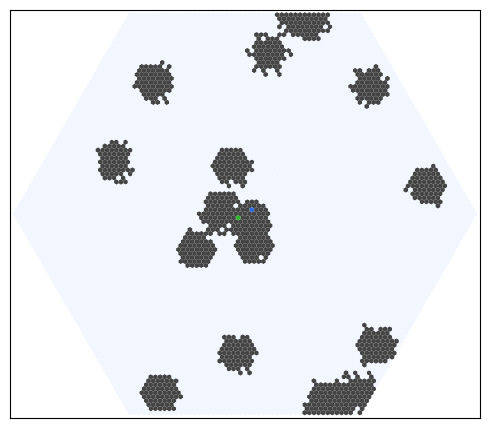

In [57]:
plot_hex_grid_2(
    obstacles,
    HexCoord(1,1),
    center,
    radius,
    goal=goal,
    figsize=(5, 5),
    show_coords=False,
    linewidth=0,
    #path=solution_path,
    draw_axes=False,
    show_axis_legend=False,
    #save_path=save_path,
    #plt_title=cache_key,
)